<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html exercisesweek34.do.txt  -->
<!-- dom:TITLE: Exercises week 34 -->

# Exercises week 34
**FYS-STK3155/4155**

Date: **August 17-21, 2026**

## Exercises

Here are three possible exercises for week 34

## Exercise 1: Setting up various Python environments

The first exercise here is of a mere technical art. We want you to have 
* git as a version control software and to establish a user account on a provider like GitHub. Other providers like GitLab etc are equally fine. You can also use the University of Oslo [GitHub facilities](https://www.uio.no/tjenester/it/maskin/filer/versjonskontroll/github.html). 

* Install various Python packages

We will make extensive use of Python as programming language and its
myriad of available libraries.  You will find
IPython/Jupyter notebooks invaluable in your work.  You can run **R**
codes in the Jupyter/IPython notebooks, with the immediate benefit of
visualizing your data. You can also use compiled languages like C++,
Rust, Fortran etc if you prefer. The focus in these lectures will be
on Python.

If you have Python installed (we recommend Python3) and you feel
pretty familiar with installing different packages, we recommend that
you install the following Python packages via **pip** as 

1. pip install numpy scipy matplotlib ipython scikit-learn sympy pandas pillow 

For **Tensorflow**, we recommend following the instructions in the text of 
[Aurelien Geron, Hands‑On Machine Learning with Scikit‑Learn and TensorFlow, O'Reilly](http://shop.oreilly.com/product/0636920052289.do)

We will come back to **tensorflow** later. 

For Python3, replace **pip** with **pip3**.

For OSX users we recommend, after having installed Xcode, to
install **brew**. Brew allows for a seamless installation of additional
software via for example 

1. brew install python3

For Linux users, with its variety of distributions like for example the widely popular Ubuntu distribution,
you can use **pip** as well and simply install Python as 

1. sudo apt-get install python3  (or python for Python2.7)

If you don't want to perform these operations separately and venture
into the hassle of exploring how to set up dependencies and paths, we
recommend two widely used distrubutions which set up all relevant
dependencies for Python, namely 

* [Anaconda](https://docs.anaconda.com/), 

which is an open source
distribution of the Python and R programming languages for large-scale
data processing, predictive analytics, and scientific computing, that
aims to simplify package management and deployment. Package versions
are managed by the package management system **conda**. 

* [Enthought canopy](https://www.enthought.com/product/canopy/) 

is a Python
distribution for scientific and analytic computing distribution and
analysis environment, available for free and under a commercial
license.

We recommend using **Anaconda** if you are not too familiar with setting paths in a terminal environment.

## Exercise 2: making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x \in [0,1]$ and defined by random numbers computed with the uniform distribution. The function $y$ is a quadratic polynomial in $x$ with added stochastic noise according to the normal distribution $\cal {N}(0,1)$.
The following simple Python instructions define our $x$ and $y$ values (with 100 data points).

In [3]:
import numpy as np
x = np.random.rand(100,1)
y = 2.0+5*x*x+0.1*np.random.randn(100,1)

1. Write your own code (following the examples under the [regression notes](https://compphysics.github.io/MachineLearning/doc/LectureNotes/_build/html/chapter1.html)) for computing the parametrization of the data set fitting a second-order polynomial. 

$\tilde{y} = X\Theta$,  $\tilde{y_i} = \sum_{j=0}^{p-1}x_{ij}\Theta_j=X_{i,*}\Theta$

In [4]:
# Design Matrice
n = len(x)
X = np.zeros((n, 3))
print(x.shape)
for i in range(n):
    for k in range(3):
        X[i, k] = (x[i]**k)[0]


(100, 1)


(3, 3)
(100, 3)
(3, 1)


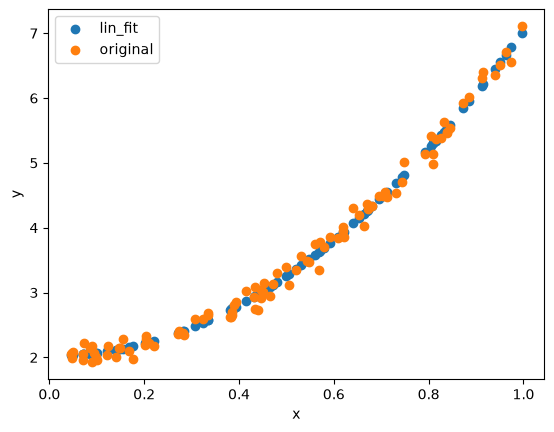

In [5]:
import matplotlib.pyplot as plt
def ols(X,y):
    "Ordinary least squares through the SVD"
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    T = Vt.T @ (U.T @ y / s)
    return T
Theta = ols(X,y)
print(Theta.shape)
print(X.shape)

def ols_normal_equations(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

Theta1 = ols_normal_equations(X,y)
print(Theta1.shape)
y_tilde = (X @ Theta1)
plt.scatter(x,y_tilde, label="lin_fit")
plt.scatter(x,y, label="original")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


2. Use thereafter **scikit-learn** (see again the examples in the regression slides) and compare with your own code.

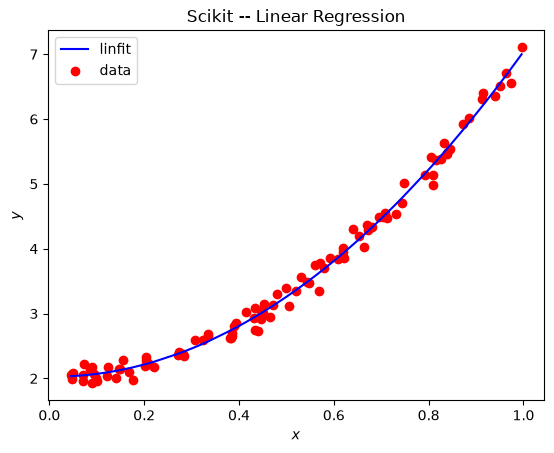

In [6]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)
ypredict = linreg.predict(X)

x_index = np.argsort(x.ravel())

plt.plot(x[x_index], ypredict[x_index], c="b", label = "linfit")
plt.scatter(x[x_index], y[x_index] ,c='r', label="data")
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Scikit -- Linear Regression')
plt.legend()
plt.show()


1. Using scikit-learn, compute also the mean square error, a risk metric corresponding to the expected value of the squared (quadratic) error defined as

$$
MSE(\boldsymbol{y},\boldsymbol{\tilde{y}}) = \frac{1}{n}
\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
$$

and the $R^2$ score function.
If $\tilde{\boldsymbol{y}}_i$ is the predicted value of the $i-th$ sample and $y_i$ is the corresponding true value, then the score $R^2$ is defined as

$$
R^2(\boldsymbol{y}, \tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n - 1} (y_i - \tilde{y}_i)^2}{\sum_{i=0}^{n - 1} (y_i - \bar{y})^2},
$$

where we have defined the mean value  of $\boldsymbol{y}$ as

$$
\bar{y} =  \frac{1}{n} \sum_{i=0}^{n - 1} y_i.
$$

You can use the functionality included in scikit-learn. If you feel for it, you can use your own program and define functions which compute the above two functions. 
Discuss the meaning of these results. Try also to vary the coefficient in front of the added stochastic noise term and discuss the quality of the fits.

In [7]:
# Mean squared error
def mean_squared_error(y, y_t):
    return np.mean((y - y_t)**2)

MSE_Reg = mean_squared_error(y, y_tilde) 
MSE_sklearn = mean_squared_error(y, ypredict)
print(f"MSE from OLS: {MSE_Reg}")
print(f"MSE from sklearn: {MSE_sklearn}")

def R_squared(y, y_t):
    return 1 - np.sum((y - y_t)**2) / np.sum((y - np.mean(y))**2)

R2_Reg = R_squared(y, y_tilde)
R2_sklearn = R_squared(y, ypredict)
print(f"R² from OLS: {R2_Reg}")
print(f"R² from sklearn: {R2_sklearn}")


MSE from OLS: 0.012392448951729718
MSE from sklearn: 0.01239244895172972
R² from OLS: 0.9935712001596089
R² from sklearn: 0.9935712001596089


## Exercise 3: Split data in test and training data

In this exercise we want you to to compute the MSE for the training
data and the test data as function of the complexity of a polynomial,
that is the degree of a given polynomial.

The aim is to reproduce Figure 2.11 of [Hastie et al](https://github.com/CompPhysics/MLErasmus/blob/master/doc/Textbooks/elementsstat.pdf).

Our data is defined by $x\in [-3,3]$ with a total of for example $n=100$ data points. You should try to vary the number of data points $n$ in your analysis.

In [43]:
np.random.seed()
n = 100
# Make data set.
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2)+ np.random.normal(0, 0.1, x.shape)

where $y$ is the function we want to fit with a given polynomial.

**a)**
Write a first code which sets up a design matrix $X$ defined by a fifth-order polynomial and split your data set in training and test data.

In [44]:
x, y = np.ravel(x), np.ravel(y)
degree = 5
columns = []
for total in range(degree + 1):
    for b in range(total + 1):
        columns.append((x**(total-b)) * (y**b))
X = np.column_stack(columns) 
print(X.shape) 
# A fift order fit in two variables has 21 parameters 

(100, 21)


In [45]:
X_test = X[0:50,:]
X_train = X[50:,:]
y_test = y[0:50]
y_train = y[50:]
print(X_test.shape, X_train.shape, y_test.shape, y_train.shape)


(50, 21) (50, 21) (50,) (50,)


**b)**
Write thereafter (using either **scikit-learn** or your matrix inversion code using for example **numpy**)
and perform an ordinary least squares fitting and compute the mean squared error for the training data and the test data. These calculations should apply to a model given by a fifth-order polynomial.

MSE train: 4.934033320861111e-11
MSE test: 4.617342301460904e-05


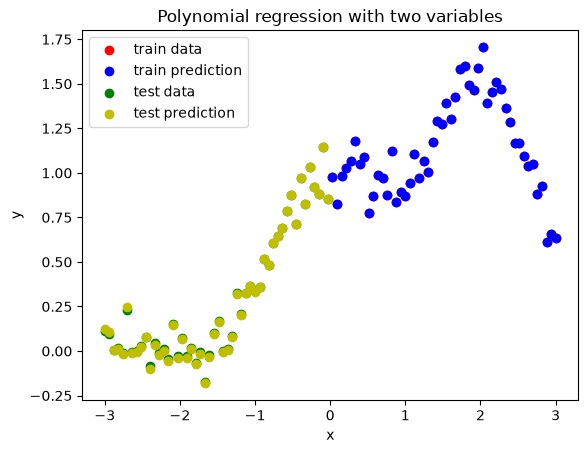

In [46]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
ypredict_train = linreg.predict(X_train)
ypredict_test = linreg.predict(X_test)
#print(ypredict_train, ypredict_test)

MSE_train = mean_squared_error(y_train, ypredict_train)
MSE_test = mean_squared_error(y_test, ypredict_test)
print(f"MSE train: {MSE_train}")
print(f"MSE test: {MSE_test}")

plt.scatter(x[50:], y_train, c='r', label="train data")
plt.scatter(x[50:], ypredict_train, c='b', label="train prediction")
plt.scatter(x[0:50], y_test, c='g', label="test data")
plt.scatter(x[0:50], ypredict_test, c='y', label="test prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial regression with two variables")
plt.legend()
plt.show()

**c)**
Add now a model which allows you to make polynomials up to degree $15$.  Perform a standard OLS fitting of the training data and compute the MSE for the training and test data and plot both test and training data MSE as functions of the polynomial degree. Compare what you see with Figure 2.11 of Hastie et al. Comment your results. For which polynomial degree do you find an optimal MSE (smallest value)?

MSE train list: [np.float64(2.1200636827814692e-32), np.float64(1.3139464452587478e-31), np.float64(2.2950921961273813e-31), np.float64(1.9159459235555324e-30), np.float64(4.934033320861111e-11), np.float64(3.077992381901908e-09), np.float64(3.699589749738536e-08), np.float64(1.771008141683298e-07), np.float64(1.192951518616908e-06), np.float64(3.241335455487983e-06), np.float64(9.262839661794914e-06), np.float64(0.00015811021416985865), np.float64(0.0008181177122082415), np.float64(0.00140858176206595), np.float64(0.0044770327352271905)]
MSE test list: [np.float64(1.4313533916177473e-31), np.float64(9.845069970311939e-30), np.float64(6.705338345463355e-30), np.float64(5.5271684933378476e-27), np.float64(4.617342301460904e-05), np.float64(8.47609761609326), np.float64(17.100663865853935), np.float64(745.9840924880776), np.float64(2202.0764158517068), np.float64(8678.751155157668), np.float64(22394.857111234032), np.float64(801260.1877118462), np.float64(360727.2482831009), np.float64(3

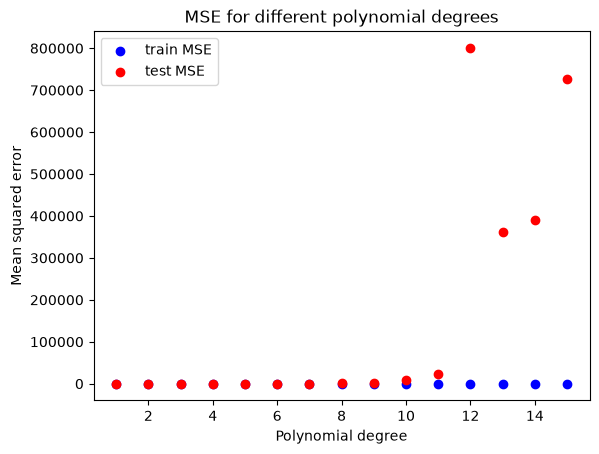

In [47]:
def design_matrix_2D(x,y,degree):
    x, y = np.ravel(x), np.ravel(y)
    columns = []
    for total in range(degree + 1):
        for b in range(total + 1):
            columns.append((x**(total-b)) * (y**b))
    return np.column_stack(columns) 

deg_list = np.linspace(1, 15, 15, dtype=int)
p = (deg_list+1)*(deg_list+2)/2
MSE_train_list = []
MSE_test_list = []
for deg in deg_list:
    X = design_matrix_2D(x, y, deg)
    X_test = X[0:50,:]
    X_train = X[50:,:]
    y_test = y[0:50] # Denne dataen blir jo ikke brukt til noe? 
    y_train = y[50:] 

    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    ypredict_train = linreg.predict(X_train)
    ypredict_test = linreg.predict(X_test)
    MSE_train = np.mean((ypredict_train - y_train)**2)
    MSE_test = np.mean((ypredict_test - y_test)**2)
    MSE_train_list.append(MSE_train)
    MSE_test_list.append(MSE_test)
print(f"MSE train list: {MSE_train_list}")
print(f"MSE test list: {MSE_test_list}")
print(f"Number of parameters: {p}")

plt.scatter(deg_list, MSE_train_list, c='b', label="train MSE")
plt.scatter(deg_list, MSE_test_list, c='r', label="test MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error")
plt.title("MSE for different polynomial degrees")
plt.legend()
plt.show()

This seems strange, by the MSE it seems degree 1 is best, the linear model. Also degree 1-4 show a low MSE for the test data, from degree 5 and onwards the MSE increase rapidly, indicating that the model is overfitting. For degree 13 14 and 15 there are more parameters than data points! 100 data points and respectively 105, 120 and 136, no good!